# USD Rates RV — Carry / roll-down & cross-structure screener

Showcases `RVUtils.carry_roll`, `RVUtils.screener_rv` (composite rank + RV dislocation index) and the ING PC1-residual vs carry/roll 'double-alpha' scatter on the SOFR curve.

In [1]:
%matplotlib inline
import sys; sys.path.append("../../")
import datetime, pytz, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 6); plt.rcParams["axes.grid"] = True
from RVUtils.plt_timeseries import make_secondary_axis_plot

NYC = pytz.timezone("America/New_York")
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts = TimeseriesBuilder()
start = NYC.localize(datetime.datetime(2025, 6, 2, 17, 0))
end = NYC.localize(datetime.datetime(2026, 6, 17, 17, 0))
ROUTERS = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=False), "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=False)}
YRS = {"2y": 2, "3y": 3, "5y": 5, "7y": 7, "10y": 10, "20y": 20, "30y": 30}
MAT = {"CT2": 2, "CT3": 3, "CT5": 5, "CT7": 7, "CT10": 10, "CT20": 20, "CT30": 30}

def load(queries):
    return ts.get_timeseries(start=start, end=end, queries=queries, n_jobs=8, routers=ROUTERS)

def sofr(tenors):
    df = load([UnifiedQuery(curve="USD-SOFR-1D", tenor=t, value=UnifiedValue.IRS_RATE) for t in tenors])
    return df.rename(columns={f"USD-SOFR-1D {t} OUTRIGHT RATE": t for t in tenors})[list(tenors)]

def ust(cts):
    df = load([UnifiedQuery(cusip=c, value=UnifiedValue.FRB_YTM) for c in cts])
    return df.rename(columns={f"{c} OUTRIGHT YTM": c for c in cts})[list(cts)]

print("Setup OK. Window:", start.date(), "->", end.date())

Setup OK. Window: 2025-06-02 -> 2026-06-17


In [2]:
TEN = ["2y","3y","5y","7y","10y","20y","30y"]
df_s = sofr(TEN)
curve_ts = df_s.rename(columns=YRS)   # float tenor columns for carry/roll
curve_ts.tail(3)

,2,3,5,7,10,20,30
Date,,,,,,,
2026-06-15,3.922587,3.905793,3.912999,3.971968,4.075915,4.311921,4.273636
2026-06-16,3.906366,3.884688,3.885388,3.943336,4.045849,4.281858,4.246070
2026-06-17,3.905107,3.878312,3.876028,3.927737,4.029726,4.264042,4.224857


### 3-month carry + roll-down for a curve and a fly

In [3]:
from RVUtils.carry_roll import make_carry_roll_builder
roll_ts, carry_ts, total_ts, be_ts, ctv_ts, getd = make_carry_roll_builder(curve_ts, horizon=0.25)
cr_curve = total_ts(("curve", 2, 10)) * 100
cr_fly   = total_ts(("fly", [2,5,10], [-1,2,-1])) * 100
print("2s10s 3m carry+roll:", round(cr_curve.iloc[-1],2), "bp | 2s5s10s fly:", round(cr_fly.iloc[-1],2), "bp")

2s10s 3m carry+roll: 3.2 bp | 2s5s10s fly: 0.72 bp


### Cross-structure composite screener + RV dislocation index

In [4]:
from RVUtils.screener_rv import make_rv_screener
S = {}
S["2s5s10s"]  = (2*df_s["5y"]  - df_s["2y"] - df_s["10y"]) * 100
S["5s10s30s"] = (2*df_s["10y"] - df_s["5y"] - df_s["30y"]) * 100
S["3s7s10s"]  = (2*df_s["7y"]  - df_s["3y"] - df_s["10y"]) * 100
S["2s10s"]    = (df_s["10y"] - df_s["2y"]) * 100
S["5s30s"]    = (df_s["30y"] - df_s["5y"]) * 100
S["10s30s"]   = (df_s["30y"] - df_s["10y"]) * 100
structs = pd.DataFrame(S)
cmap = {"2s5s10s":("fly",[2,5,10],[-1,2,-1]), "5s10s30s":("fly",[5,10,30],[-1,2,-1]), "3s7s10s":("fly",[3,7,10],[-1,2,-1]), "2s10s":("curve",2,10), "5s30s":("curve",5,30), "10s30s":("curve",10,30)}
carry_df = pd.DataFrame({k: total_ts(v)*100 for k, v in cmap.items()})
build, rank, to_df, di_fn, getd2 = make_rv_screener(structs, carry_df=carry_df, zscore_window=65, vol_window=20)
rank(6)[["level","zscore","percentile","vol","carry","carry_to_vol","half_life","composite","direction"]].round(2)

,level,zscore,percentile,vol,carry,carry_to_vol,half_life,composite,direction
structure,,,,,,,,,
3s7s10s,-5.26,-2.50,0.02,11.49,1.75,0.15,43.35,-0.37,BUY
2s10s,12.46,-1.99,0.02,28.43,3.20,0.11,40.28,-0.32,BUY
5s10s30s,-4.14,-1.07,0.12,34.27,2.49,0.07,1.69,-0.31,BUY
5s30s,34.88,-1.31,0.12,54.66,-0.01,-0.00,22.65,-0.28,BUY
10s30s,19.51,-0.99,0.20,41.47,-1.25,-0.03,14.23,-0.27,BUY
2s5s10s,-18.28,0.67,0.66,18.55,0.72,0.04,14.79,0.23,SELL


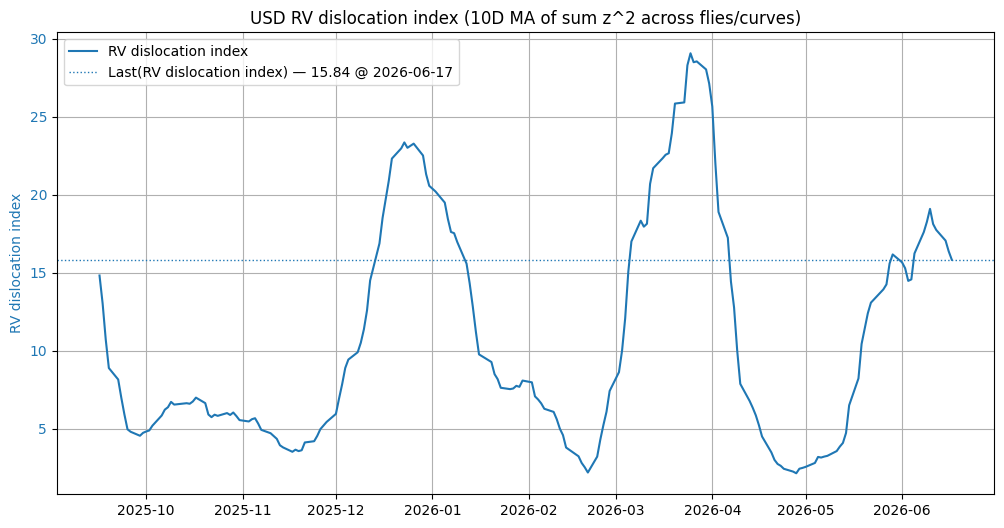

In [5]:
di = di_fn()
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="matplotlib", title="USD RV dislocation index (10D MA of sum z^2 across flies/curves)")
plot(di.rename("RV dislocation index"), which="left", indicators=[{"kind":"last"}])
legend(show_date=True, loc="upper left"); plt.show()

### ING 'double-alpha' scatter: PCA residual (rich/cheap) vs 3m roll-down per tenor

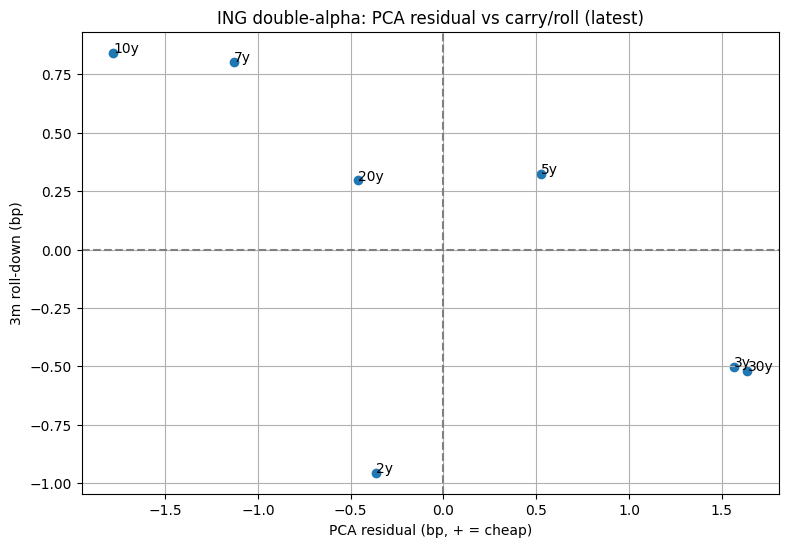

In [6]:
from RVUtils.pca_rv import make_pca_rv_builder
bp = make_pca_rv_builder(curve_ts, on="levels", n_factors=3, sort_by_tenor=False)
bp[0]()
fvtab = bp[1](k=3)
resid_latest = (curve_ts.iloc[-1] - fvtab.iloc[-1]) * 100
roll_latest = pd.Series({t: roll_ts(("outright", t)).iloc[-1]*100 for t in curve_ts.columns})
fig2, axx = plt.subplots(figsize=(9,6))
axx.scatter(resid_latest.values, roll_latest.values)
for t in curve_ts.columns: axx.annotate(f"{int(t)}y", (resid_latest[t], roll_latest[t]))
axx.axhline(0, color="grey", ls="--"); axx.axvline(0, color="grey", ls="--")
axx.set_xlabel("PCA residual (bp, + = cheap)"); axx.set_ylabel("3m roll-down (bp)")
axx.set_title("ING double-alpha: PCA residual vs carry/roll (latest)"); plt.show()